
# Triadic Cell Notebook v8
## Pattern storage, partial-cue recall, interference, rewrite stability

v7 gave a valid substrate checkpoint:

- BTR was the only case high on coherence, statefulness, readability, memory, effective focus, and slot divergence
- routed memory was no longer flat
- the baseline stayed weak

This notebook turns that substrate into a **task**.

## What v8 measures

1. **Pattern storage**
   - can the machine write distinct patterns into memory?

2. **Partial-cue recall**
   - can it recover the right slot from incomplete input?

3. **Interference**
   - does writing one pattern smear into other slots?

4. **Rewrite stability**
   - when one stored pattern is updated, do the other slots stay intact?

That is the first real memory benchmark built on top of the triadic cell.



## Hardware translation

Use the machine picture directly:

- **Binding (B)** = preserve identity and protect writes
- **Transformation (T)** = update latent state toward targets
- **Readout (R)** = expose meaningful delta
- **Address lines** = fixed slot keys
- **Recall path** = addressed read
- **Commit path** = selective write

The benchmark question is no longer just:

> does the machine stay alive?

It is now:

> does the machine store, recall, and rewrite distinct memories better than the baseline?


In [1]:

from __future__ import annotations

from dataclasses import dataclass
from typing import Dict, List, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = True
np.set_printoptions(suppress=True, precision=4)

rng = np.random.default_rng(42)

print("Environment ready.")


Environment ready.


In [2]:

@dataclass
class AddressedTriadicState:
    coherence: float = 0.72
    latent: np.ndarray = None
    readout: np.ndarray = None

    def __post_init__(self):
        if self.latent is None:
            self.latent = np.array([0.20, 0.35, 0.50, 0.15], dtype=float)
        if self.readout is None:
            self.readout = np.zeros(2, dtype=float)


In [3]:

class KeyedMemoryBank:
    def __init__(self, width: int = 4, leak: float = 0.015):
        self.width = width
        self.leak = float(leak)

        self.keys = np.array([
            [1.0, 0.2, 0.0, 0.0],
            [0.0, 1.0, 0.2, 0.0],
            [0.2, 0.0, 1.0, 0.2],
            [0.0, 0.2, 0.0, 1.0],
        ], dtype=float)
        self.keys = self.keys / np.linalg.norm(self.keys, axis=1, keepdims=True)

        self.slots = np.zeros((4, width), dtype=float)

    @staticmethod
    def _softmax(x: np.ndarray, temp: float = 1.0) -> np.ndarray:
        z = (x - np.max(x)) / max(temp, 1e-8)
        e = np.exp(z)
        return e / np.sum(e)

    def address(self, query: np.ndarray, content_mix: float = 0.15) -> np.ndarray:
        q = query / (np.linalg.norm(query) + 1e-8)
        key_scores = self.keys @ q

        if np.any(self.slots > 0):
            slot_norms = np.linalg.norm(self.slots, axis=1, keepdims=True) + 1e-8
            slot_dirs = self.slots / slot_norms
            content_scores = slot_dirs @ q
        else:
            content_scores = np.zeros_like(key_scores)

        scores = (1.0 - content_mix) * key_scores + content_mix * content_scores
        return self._softmax(scores, temp=0.08)

    def read(self, weights: np.ndarray) -> np.ndarray:
        return weights @ self.slots

    def write(self, weights: np.ndarray, value: np.ndarray, strength: float, topk: int = 2):
        self.slots *= (1.0 - self.leak)

        idx = np.argsort(weights)[::-1][:topk]
        masked = np.zeros_like(weights)
        masked[idx] = weights[idx]
        if masked.sum() > 0:
            masked = masked / masked.sum()

        for i in range(self.slots.shape[0]):
            self.slots[i] = np.clip(
                self.slots[i] + strength * masked[i] * value,
                0.0, 1.0
            )

        return masked.copy()

    def mean_level(self) -> float:
        return float(self.slots.mean())

    def slot_energy(self) -> np.ndarray:
        return self.slots.mean(axis=1)

    def divergence(self) -> float:
        e = self.slot_energy()
        if np.allclose(e.sum(), 0.0):
            return 0.0
        return float(np.std(e))



## Triadic model and baseline

Both models expose the same interface:

- `step(...)` for normal evolution and writing
- `probe(...)` for read-only query and recall

That lets us benchmark storage and recall directly.


In [4]:

class TriadicCellV8:
    def __init__(self, B: float, T: float, R: float):
        self.B = float(B)
        self.T = float(T)
        self.R = float(R)

        self.W_readout = np.array([
            [1.0, 0.2, 0.0, -0.3],
            [0.0, 0.8, -0.4, 0.6],
        ], dtype=float)

        self.W_query = np.array([
            [1.0, 0.0, 0.3, 0.0],
            [0.0, 1.0, 0.0, 0.4],
            [0.3, 0.0, 1.0, 0.0],
            [0.0, 0.4, 0.0, 1.0],
        ], dtype=float)

    @staticmethod
    def _clip(x):
        return np.clip(x, 0.0, 1.0)

    def _query(self, latent: np.ndarray) -> np.ndarray:
        raw_query = self.W_query @ latent
        return raw_query / (np.linalg.norm(raw_query) + 1e-8)

    def probe(self, cue: np.ndarray, bank: KeyedMemoryBank):
        query = self._query(cue)
        addr = bank.address(query, content_mix=0.15)
        recalled = bank.read(addr)
        return addr.copy(), recalled.copy()

    def step(
        self,
        s: AddressedTriadicState,
        drive_vec: np.ndarray,
        bank: KeyedMemoryBank,
        write_enabled: bool = True,
    ):
        query = self._query(s.latent)
        addr = bank.address(query, content_mix=0.15)
        recalled = bank.read(addr)

        load = np.linalg.norm(s.readout) + 0.2 * np.linalg.norm(recalled)
        coherence_restore = 0.05 * self.B * (0.84 - s.coherence)
        coherence_burn = 0.07 * self.T * (1.0 - self.B) + 0.008 * load
        coherence = float(np.clip(s.coherence + coherence_restore - coherence_burn, 0.0, 1.0))

        composite_target = 0.72 * drive_vec + 0.28 * recalled
        follow = 0.20 * self.B * self.T * coherence * (composite_target - s.latent)
        static_drag = 0.04 * (1.0 - self.T) * (s.latent - np.array([0.20, 0.35, 0.50, 0.15]))
        unsupported_loss = 0.14 * self.T * (1.0 - self.B) * s.latent
        latent = self._clip(s.latent + follow - static_drag - unsupported_loss)

        delta_vec = np.abs(latent - s.latent)

        support = self.B * self.T * self.R * coherence
        projected = self.W_readout @ delta_vec
        projected = np.maximum(projected, 0.0)

        shell_decay = (0.18 * (1.0 - self.T) + 0.12 * (1.0 - self.R)) * s.readout
        readout = self._clip(0.82 * s.readout + 2.25 * support * projected - shell_decay)

        write_strength = float(0.60 * support * readout.mean())
        if write_enabled:
            bank.write(addr, latent, write_strength, topk=2)

        next_state = AddressedTriadicState(
            coherence=coherence,
            latent=latent,
            readout=readout,
        )
        return next_state, readout.copy(), delta_vec.copy(), recalled.copy(), addr.copy(), write_strength


class PlainTRBaselineV8:
    def __init__(self):
        self.W_readout = np.array([
            [1.0, 0.2, 0.0, -0.3],
            [0.0, 0.8, -0.4, 0.6],
        ], dtype=float)

    @staticmethod
    def _clip(x):
        return np.clip(x, 0.0, 1.0)

    def probe(self, cue: np.ndarray, bank: KeyedMemoryBank):
        query = cue / (np.linalg.norm(cue) + 1e-8)
        addr = bank.address(query, content_mix=0.15)
        recalled = bank.read(addr)
        return addr.copy(), recalled.copy()

    def step(
        self,
        s: AddressedTriadicState,
        drive_vec: np.ndarray,
        bank: KeyedMemoryBank,
        write_enabled: bool = True,
    ):
        query = s.latent / (np.linalg.norm(s.latent) + 1e-8)
        addr = bank.address(query, content_mix=0.15)
        recalled = bank.read(addr)

        coherence = float(np.clip(s.coherence - 0.08 - 0.02 * np.linalg.norm(s.readout), 0.0, 1.0))

        composite_target = 0.72 * drive_vec + 0.28 * recalled
        latent = self._clip(s.latent + 0.10 * coherence * (composite_target - s.latent) - 0.18 * s.latent)

        delta_vec = np.abs(latent - s.latent)
        projected = self.W_readout @ delta_vec
        projected = np.maximum(projected, 0.0)
        readout = self._clip(0.65 * s.readout + 1.35 * projected - 0.35 * s.readout)

        write_strength = float(0.08 * readout.mean())
        if write_enabled:
            bank.write(addr, latent, write_strength, topk=2)

        next_state = AddressedTriadicState(
            coherence=coherence,
            latent=latent,
            readout=readout,
        )
        return next_state, readout.copy(), delta_vec.copy(), recalled.copy(), addr.copy(), write_strength



## Prototype patterns

These are the distinct patterns we want the memory bank to store.

They are chosen to align with the keyed slots while still being different enough to interfere if the machine is weak.


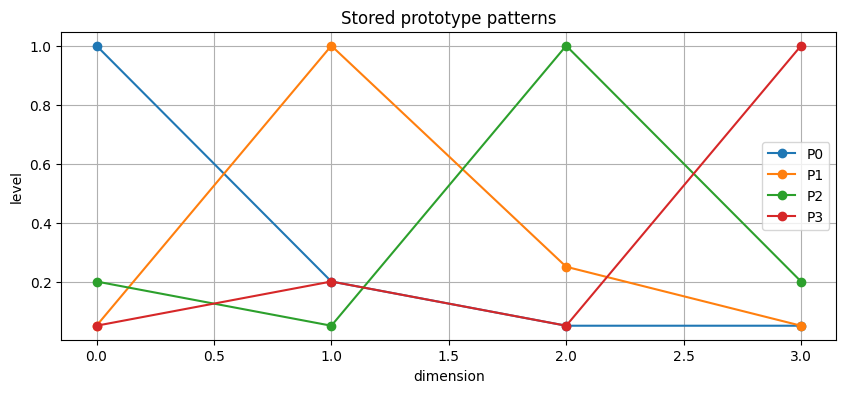

,d0,d1,d2,d3
P0,1.00,0.20,0.05,0.05
P1,0.05,1.00,0.25,0.05
P2,0.20,0.05,1.00,0.20
P3,0.05,0.20,0.05,1.00


In [5]:

patterns = np.array([
    [1.00, 0.20, 0.05, 0.05],
    [0.05, 1.00, 0.25, 0.05],
    [0.20, 0.05, 1.00, 0.20],
    [0.05, 0.20, 0.05, 1.00],
], dtype=float)

pattern_names = [f"P{i}" for i in range(patterns.shape[0])]

plt.figure(figsize=(10, 4))
for i, p in enumerate(patterns):
    plt.plot(p, marker="o", label=pattern_names[i])
plt.title("Stored prototype patterns")
plt.xlabel("dimension")
plt.ylabel("level")
plt.legend(loc="best")
plt.show()

pd.DataFrame(patterns, index=pattern_names, columns=[f"d{i}" for i in range(4)])



## Helpers


In [6]:

def cosine_similarity(a: np.ndarray, b: np.ndarray) -> float:
    na = np.linalg.norm(a) + 1e-8
    nb = np.linalg.norm(b) + 1e-8
    return float(np.dot(a, b) / (na * nb))


def partial_cue(pattern: np.ndarray, mask_prob: float = 0.5, noise: float = 0.04) -> np.ndarray:
    cue = pattern.copy()
    mask = rng.random(pattern.shape[0]) < mask_prob
    cue[mask] = 0.0
    cue += rng.normal(0.0, noise, size=cue.shape[0])
    cue = np.clip(cue, 0.0, 1.0)
    return cue


def store_patterns(model, bank: KeyedMemoryBank, cycles_per_pattern: int = 18):
    state = AddressedTriadicState()
    for p in patterns:
        for _ in range(cycles_per_pattern):
            drive = np.clip(p + rng.normal(0.0, 0.03, size=p.shape[0]), 0.0, 1.0)
            state, *_ = model.step(state, drive, bank, write_enabled=True)
    return state


def probe_patterns(model, bank: KeyedMemoryBank, trials_per_pattern: int = 24) -> pd.DataFrame:
    rows = []
    for idx, p in enumerate(patterns):
        for trial in range(trials_per_pattern):
            cue = partial_cue(p, mask_prob=0.5, noise=0.04)
            addr, recalled = model.probe(cue, bank)
            pred_slot = int(np.argmax(addr))
            sim = cosine_similarity(recalled, p)
            rows.append({
                "target_slot": idx,
                "pred_slot": pred_slot,
                "slot_focus": float(addr.max()),
                "recall_similarity": sim,
                "cue_mean": float(cue.mean()),
            })
    return pd.DataFrame(rows)


def rewrite_one_pattern(model, bank: KeyedMemoryBank, slot_idx: int = 2, cycles: int = 16):
    before = bank.slot_energy().copy()
    modified = patterns[slot_idx].copy()
    modified = np.clip(modified * np.array([0.85, 1.10, 0.90, 1.05]), 0.0, 1.0)

    state = AddressedTriadicState()
    for _ in range(cycles):
        drive = np.clip(modified + rng.normal(0.0, 0.03, size=modified.shape[0]), 0.0, 1.0)
        state, *_ = model.step(state, drive, bank, write_enabled=True)

    after = bank.slot_energy().copy()
    target_shift = float(abs(after[slot_idx] - before[slot_idx]))
    collateral_shift = float(np.mean(np.abs(np.delete(after, slot_idx) - np.delete(before, slot_idx))))

    return {
        "slot_idx": slot_idx,
        "target_shift": target_shift,
        "collateral_shift": collateral_shift,
        "rewrite_ratio": float(target_shift / (collateral_shift + 1e-8)),
    }



## Run the benchmark


In [7]:

def run_benchmark(label: str, triadic: bool = True):
    if triadic:
        model = TriadicCellV8(1.0, 1.0, 1.0)
    else:
        model = PlainTRBaselineV8()

    bank = KeyedMemoryBank(width=4, leak=0.015)
    _ = store_patterns(model, bank, cycles_per_pattern=18)
    slot_energy_after_store = bank.slot_energy().copy()

    probe_df = probe_patterns(model, bank, trials_per_pattern=24)

    accuracy = float((probe_df["pred_slot"] == probe_df["target_slot"]).mean())
    mean_similarity = float(probe_df["recall_similarity"].mean())
    mean_focus = float(probe_df["slot_focus"].mean())
    divergence = float(np.std(slot_energy_after_store))

    rewrite_stats = rewrite_one_pattern(model, bank, slot_idx=2, cycles=16)
    slot_energy_after_rewrite = bank.slot_energy().copy()

    summary = {
        "model": label,
        "retrieval_accuracy": accuracy,
        "mean_recall_similarity": mean_similarity,
        "mean_slot_focus": mean_focus,
        "slot_divergence_after_store": divergence,
        "rewrite_target_shift": rewrite_stats["target_shift"],
        "rewrite_collateral_shift": rewrite_stats["collateral_shift"],
        "rewrite_ratio": rewrite_stats["rewrite_ratio"],
    }

    return summary, probe_df, slot_energy_after_store, slot_energy_after_rewrite

triadic_summary, triadic_probe, triadic_store_energy, triadic_rewrite_energy = run_benchmark("BTR", triadic=True)
baseline_summary, baseline_probe, baseline_store_energy, baseline_rewrite_energy = run_benchmark("Plain TR baseline", triadic=False)

summary_df = pd.DataFrame([triadic_summary, baseline_summary])
summary_df


,model,retrieval_accuracy,mean_recall_similarity,mean_slot_focus,slot_divergence_after_store,rewrite_target_shift,rewrite_collateral_shift,rewrite_ratio
0,BTR,0.520833,0.700883,0.940295,0.099122,0.008278,0.041388,0.200001
1,Plain TR baseline,0.364583,0.616982,0.965005,0.000285,0.003152,0.000108,29.182498



## Probe metrics


In [8]:

probe_summary = pd.DataFrame([
    {
        "model": "BTR",
        "accuracy": (triadic_probe["pred_slot"] == triadic_probe["target_slot"]).mean(),
        "mean_similarity": triadic_probe["recall_similarity"].mean(),
        "mean_focus": triadic_probe["slot_focus"].mean(),
    },
    {
        "model": "Plain TR baseline",
        "accuracy": (baseline_probe["pred_slot"] == baseline_probe["target_slot"]).mean(),
        "mean_similarity": baseline_probe["recall_similarity"].mean(),
        "mean_focus": baseline_probe["slot_focus"].mean(),
    }
])
probe_summary


,model,accuracy,mean_similarity,mean_focus
0,BTR,0.520833,0.700883,0.940295
1,Plain TR baseline,0.364583,0.616982,0.965005


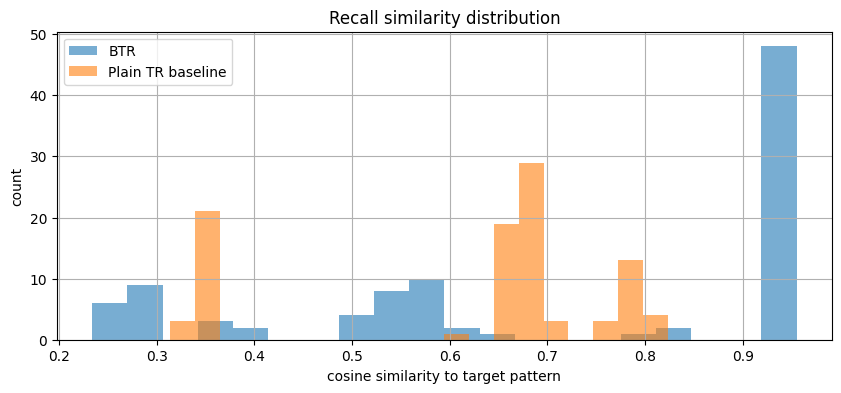

In [9]:

plt.figure(figsize=(10, 4))
plt.hist(triadic_probe["recall_similarity"], bins=20, alpha=0.6, label="BTR")
plt.hist(baseline_probe["recall_similarity"], bins=20, alpha=0.6, label="Plain TR baseline")
plt.title("Recall similarity distribution")
plt.xlabel("cosine similarity to target pattern")
plt.ylabel("count")
plt.legend(loc="best")
plt.show()



## Slot energy after store and after rewrite


In [10]:

energy_df = pd.DataFrame({
    "BTR store": triadic_store_energy,
    "BTR rewrite": triadic_rewrite_energy,
    "Baseline store": baseline_store_energy,
    "Baseline rewrite": baseline_rewrite_energy,
}, index=[f"slot_{i}" for i in range(4)])

energy_df


,BTR store,BTR rewrite,Baseline store,Baseline rewrite
slot_0,0.190476,0.149808,0.000179,0.000141
slot_1,0.319777,0.251598,0.000129,0.000415
slot_2,0.299786,0.308064,0.000743,0.003895
slot_3,0.071312,0.055994,0.000000,0.000000


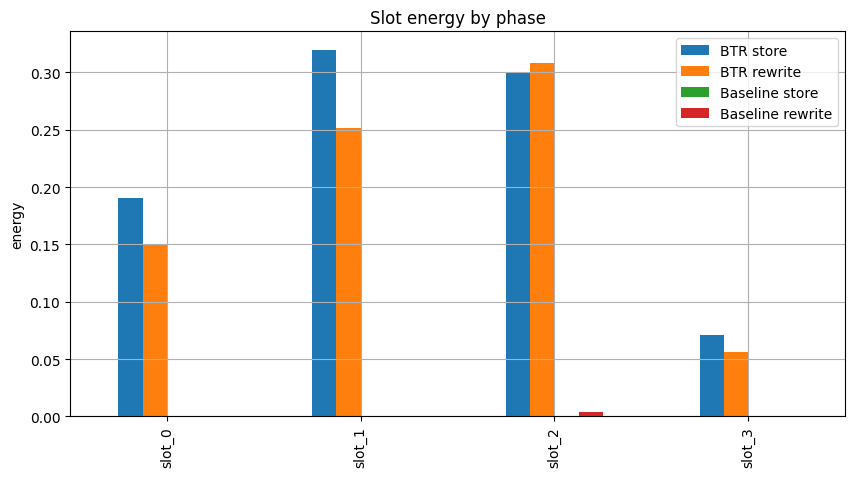

In [11]:

energy_df.plot(kind="bar", figsize=(10, 5))
plt.title("Slot energy by phase")
plt.ylabel("energy")
plt.show()



## Retrieval confusion


In [12]:

triadic_conf = pd.crosstab(triadic_probe["target_slot"], triadic_probe["pred_slot"])
baseline_conf = pd.crosstab(baseline_probe["target_slot"], baseline_probe["pred_slot"])

print("BTR confusion matrix")
display(triadic_conf)

print("Baseline confusion matrix")
display(baseline_conf)


BTR confusion matrix


pred_slot,0,1,2,3
target_slot,,,,
0,14,6,2,2
1,4,12,7,1
2,2,1,17,4
3,6,8,3,7


Baseline confusion matrix


pred_slot,0,1,2,3
target_slot,,,,
0,5,11,2,6
1,1,14,6,3
2,8,0,9,7
3,3,11,3,7



## Read the result

What you want to see:

- **BTR** should beat the baseline on retrieval accuracy
- **BTR** should beat the baseline on recall similarity
- **BTR** should keep higher slot divergence after store
- **BTR** should show better rewrite locality:
  - bigger target shift
  - smaller collateral shift
  - higher rewrite ratio

That is the first real memory benchmark on top of the substrate.
